# 1: Data generation using Accept-Reject method

Histogram of real data

Critical Thresholds (Rare Events)
Lower 1% Threshold (pH <=): 3.407
Upper 1% Threshold (pH >=): 10.895
Probability of Rare Event in Real Data: 0.020 (or 2.000000000000001%)


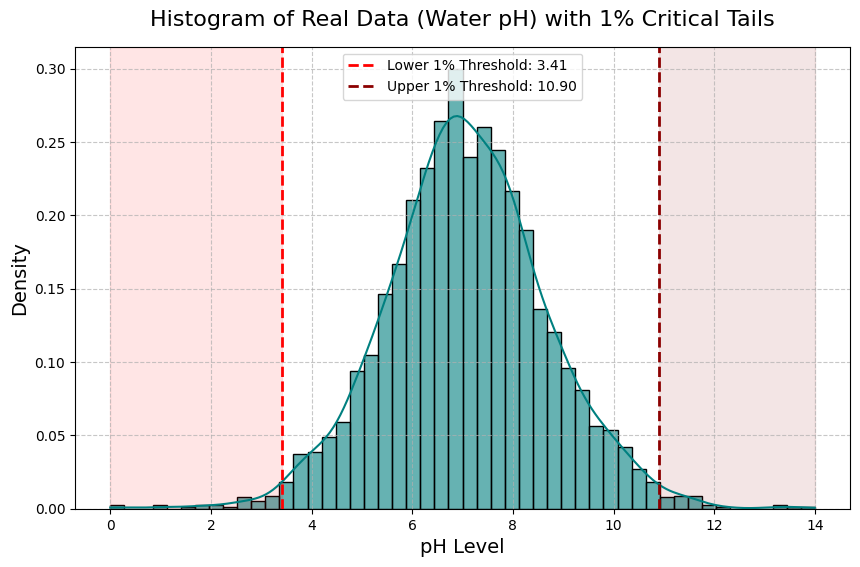

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ۱. بارگذاری دیتاست
df = pd.read_csv('water_potability.csv')

target_column = 'ph'
real_data = df[target_column].dropna()

# محاسبه ۱ درصد انتهایی سمت چپ و ۱ درصد انتهایی سمت راست
lower_percentile = 0.01
upper_percentile = 0.99

threshold_lower = real_data.quantile(lower_percentile)
threshold_upper = real_data.quantile(upper_percentile)

print(f"Critical Thresholds (Rare Events)")
print(f"Lower 1% Threshold (pH <=): {threshold_lower:.3f}")
print(f"Upper 1% Threshold (pH >=): {threshold_upper:.3f}")
print(f"Probability of Rare Event in Real Data: {(lower_percentile + (1 - upper_percentile)):.3f} (or {(lower_percentile + (1 - upper_percentile))*100}%)")

# ۳. رسم هیستوگرام داده‌های واقعی
plt.figure(figsize=(10, 6))

sns.histplot(real_data, bins=50, kde=True, color='teal', stat='density', alpha=0.6)

plt.axvline(x=threshold_lower, color='red', linestyle='--', linewidth=2, 
            label=f'Lower 1% Threshold: {threshold_lower:.2f}')
plt.axvline(x=threshold_upper, color='darkred', linestyle='--', linewidth=2, 
            label=f'Upper 1% Threshold: {threshold_upper:.2f}')

plt.axvspan(real_data.min(), threshold_lower, color='red', alpha=0.1)
plt.axvspan(threshold_upper, real_data.max(), color='darkred', alpha=0.1)

plt.title('Histogram of Real Data (Water pH) with 1% Critical Tails', fontsize=16, pad=15)
plt.xlabel('pH Level', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Fit analytical distribution

Gamma Distribution Parameters
Shape (a): 6615.4484
Loc (Shift): -122.5883
Scale (Scale): 0.0196


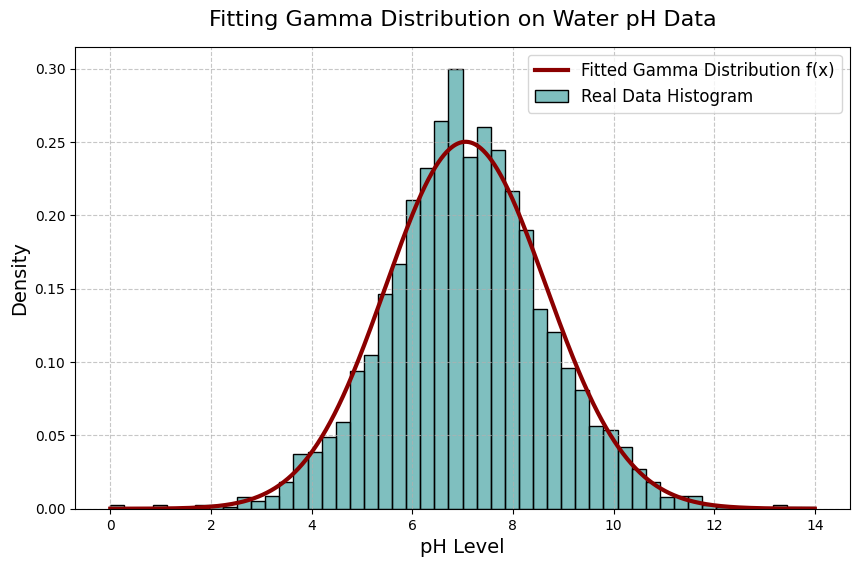

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gamma

df = pd.read_csv('water_potability.csv')
target_column = 'ph'
real_data = df[target_column].dropna()

#  برازش توزیع گاما بر روی داده‌های واقعی
shape, loc, scale = gamma.fit(real_data)

print("Gamma Distribution Parameters")
print(f"Shape (a): {shape:.4f}")
print(f"Loc (Shift): {loc:.4f}")
print(f"Scale (Scale): {scale:.4f}")

x_vals = np.linspace(real_data.min(), real_data.max(), 1000)
gamma_pdf = gamma.pdf(x_vals, shape, loc=loc, scale=scale)

plt.figure(figsize=(10, 6))

# رسم هیستوگرام داده های واقعی
sns.histplot(real_data, bins=50, stat='density', color='teal', alpha=0.5, label='Real Data Histogram')

# رسم منحنی تابع گاما (f(x))
plt.plot(x_vals, gamma_pdf, color='darkred', linewidth=3, label='Fitted Gamma Distribution f(x)')

plt.title('Fitting Gamma Distribution on Water pH Data', fontsize=16, pad=15)
plt.xlabel('pH Level', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Using the Accept-Reject algorithm, choose the Laplace function as the proposal distribution, and plot the graph

Accept-Reject Parameters
Optimal 'c' value: 1.3314
Acceptance Probability (1/c): 0.7511 (or 75.11%)


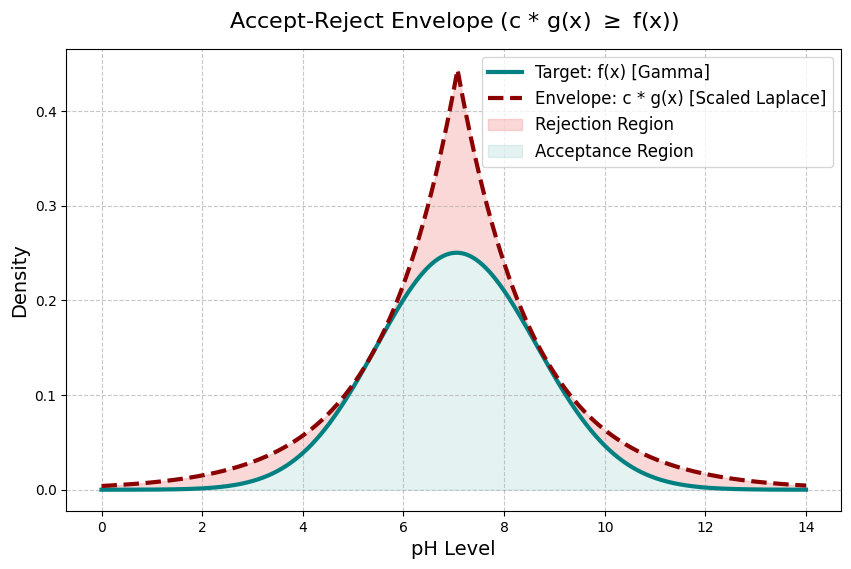

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, laplace

shape_f = 6615.4484
loc_f = -122.5883
scale_f = 0.0196

# مرکز لاپلاس را روی میانگین گاما قرار می دهیم
mean_val = loc_f + (shape_f * scale_f) 
scale_g = 1.5 

x = np.linspace(0, 14, 2000)

# محاسبه مقادیر توابع
f_x = gamma.pdf(x, shape_f, loc=loc_f, scale=scale_f)
g_x = laplace.pdf(x, loc=mean_val, scale=scale_g)

# محاسبه مقدار ی c
ratio = f_x / g_x
c = np.max(ratio)

print(f"Accept-Reject Parameters")
print(f"Optimal 'c' value: {c:.4f}")
print(f"Acceptance Probability (1/c): {(1/c):.4f} (or {(1/c)*100:.2f}%)")

plt.figure(figsize=(10, 6))

# رسم f(x)
plt.plot(x, f_x, color='teal', linewidth=3, label='Target: f(x) [Gamma]')

plt.plot(x, c * g_x, color='darkred', linewidth=3, linestyle='--', label='Envelope: c * g(x) [Scaled Laplace]')

plt.fill_between(x, f_x, c * g_x, color='lightcoral', alpha=0.3, label='Rejection Region')
plt.fill_between(x, 0, f_x, color='teal', alpha=0.1, label='Acceptance Region')

plt.title(r'Accept-Reject Envelope (c * g(x) $\geq$ f(x))', fontsize=16, pad=15)

plt.xlabel('pH Level', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Accept-Reject data generation code to produce random data


 Accept-Reject Algorithm Results
Total samples needed to generate 1000000 valid points: 1331888
Theoretical Acceptance Rate (1/c): 0.7511 (75.11%)
Actual Acceptance Rate: 0.7508 (75.08%)


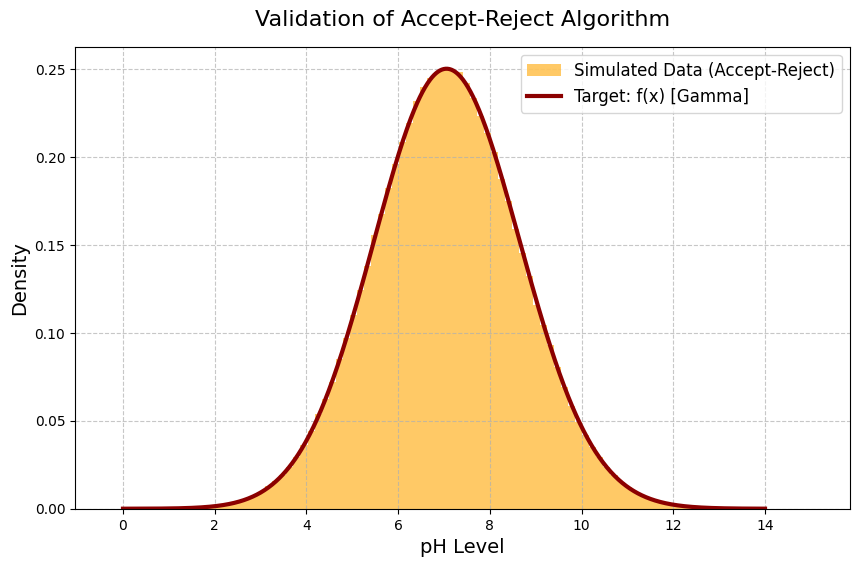

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, laplace

# پارامترهایی که  مراحل قبل به دست آوردیم 
shape_f = 6615.4484
loc_f = -122.5883
scale_f = 0.0196

# مرکز لاپلاس ( میانگین داده‌ها)
mean_val = loc_f + (shape_f * scale_f) 
scale_g = 1.5 
c = 1.3314

N_target = 1000000  
simulated_data = [] # لیستی برای ذخیره داده‌های پذیرفته شده
total_generated = 0 # شمارنده کل داده‌های تولید شده (برای محاسبه نرخ پذیرش عملی)

#   الگوریتم رد-پذیرش 
while len(simulated_data) < N_target:
    total_generated += 1
    
    u1 = np.random.uniform(0, 1)
    
    # فرمول تبدیل وارون لاپلاس 
    if u1 < 0.5:
        y = mean_val + scale_g * np.log(2 * u1)
    else:
        y = mean_val - scale_g * np.log(2 - 2 * u1)
        
    u2 = np.random.uniform(0, 1)
    
    f_y = gamma.pdf(y, shape_f, loc=loc_f, scale=scale_f)
    g_y = laplace.pdf(y, loc=mean_val, scale=scale_g)
    
    if g_y == 0:
        continue
        
    if u2 <= (f_y / (c * g_y)):
        simulated_data.append(y)

simulated_data = np.array(simulated_data)

# محاسبه نرخ پذیرش عملی
actual_acceptance_rate = N_target / total_generated
theoretical_acceptance_rate = 1 / c

print("\n Accept-Reject Algorithm Results")
print(f"Total samples needed to generate {N_target} valid points: {total_generated}")
print(f"Theoretical Acceptance Rate (1/c): {theoretical_acceptance_rate:.4f} ({theoretical_acceptance_rate*100:.2f}%)")
print(f"Actual Acceptance Rate: {actual_acceptance_rate:.4f} ({actual_acceptance_rate*100:.2f}%)")

#  رسم نمودار برای مقایسه داده های شبیه سازی شده با توزیع f(x)
plt.figure(figsize=(10, 6))

# رسم هیستوگرام داده های شبیه سازی شده
plt.hist(simulated_data, bins=100, density=True, color='orange', alpha=0.6, label='Simulated Data (Accept-Reject)')

# رسم منحنی f(x) روی آن برای اثبات صحت عملکرد
x_vals = np.linspace(0, 14, 1000)
f_x_curve = gamma.pdf(x_vals, shape_f, loc=loc_f, scale=scale_f)
plt.plot(x_vals, f_x_curve, color='darkred', linewidth=3, label='Target: f(x) [Gamma]')

plt.title('Validation of Accept-Reject Algorithm', fontsize=16, pad=15)
plt.xlabel('pH Level', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

# 2: Standard Monte Carlo


 Standard Monte Carlo Results 
N (Sample Size)  Estimated Prob (P_hat)  Absolute Error  MC Variance (S^2/N)  Number of Rare Events
           10^3                0.082000        0.062000         7.527600e-05                     82
           10^4                0.088500        0.068500         8.066775e-06                    885
           10^5                0.090230        0.070230         8.208855e-07                   9023
           10^6                0.090053        0.070053         8.194346e-08                  90053


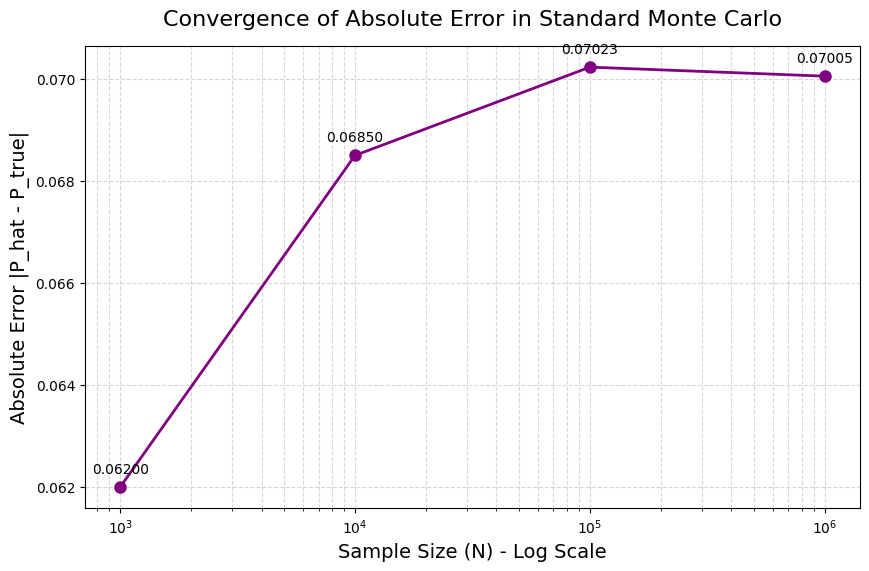

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#   تعریف آستانه های بحرانی 
# این اعداد را در گام اول از داده های واقعی به دست آوردیم. 
threshold_lower = 4.34  
threshold_upper = 9.75  

P_true = 0.02 #(1%+1%)

#   مقادیر N خواسته شده در پروژه 
N_values = [10**3, 10**4, 10**5, 10**6]

results = []


for N in N_values:
    sample_subset = simulated_data[:N]
    
    # y < threshold_lower  or  y > threshold_upper
    indicator_values = np.where((sample_subset <= threshold_lower) | (sample_subset >= threshold_upper), 1, 0)
    
    P_hat = np.mean(indicator_values)
    
    sample_variance = P_hat * (1 - P_hat)
    
    monte_carlo_variance = sample_variance / N
    
    # Absolute Error
    absolute_error = np.abs(P_hat - P_true)
    
    results.append({
        'N (Sample Size)': f"10^{int(np.log10(N))}",
        'N_int': N,
        'Estimated Prob (P_hat)': P_hat,
        'Absolute Error': absolute_error,
        'MC Variance (S^2/N)': monte_carlo_variance,
        'Number of Rare Events': np.sum(indicator_values)
    })

results_df = pd.DataFrame(results)
print("\n Standard Monte Carlo Results ")
display_cols = ['N (Sample Size)', 'Estimated Prob (P_hat)', 'Absolute Error', 'MC Variance (S^2/N)', 'Number of Rare Events']
print(results_df[display_cols].to_string(index=False))

#   رسم نمودار همگرایی خطای مطلق 
plt.figure(figsize=(10, 6))
plt.plot(results_df['N_int'], results_df['Absolute Error'], marker='o', linestyle='-', color='purple', linewidth=2, markersize=8)

plt.xscale('log') 
plt.title('Convergence of Absolute Error in Standard Monte Carlo', fontsize=16, pad=15)
plt.xlabel('Sample Size (N) - Log Scale', fontsize=14)
plt.ylabel('Absolute Error |P_hat - P_true|', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)

# اضافه کردن مقادیر خطا روی نقاط
for i, txt in enumerate(results_df['Absolute Error']):
    plt.annotate(f"{txt:.5f}", (results_df['N_int'][i], results_df['Absolute Error'][i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

plt.show()

calculate P_true using Gamma dist

We do this to make the plot consistent/logical. 
Because in the Gamma distribution fitted to our model, the area under the curve outside the critical region 
is approximately 9%, whereas the critical region itself represents the top and bottom 1% of the original data.

True Analytical Probability under Gamma Distribution: 0.089769

--- Standard Monte Carlo Results ---
N (Sample Size)  Estimated Prob (P_hat)  Absolute Error  MC Variance (S^2/N)  Number of Rare Events
           10^3                0.082000        0.007769         7.527600e-05                     82
           10^4                0.088500        0.001269         8.066775e-06                    885
           10^5                0.090230        0.000461         8.208855e-07                   9023
           10^6                0.090053        0.000284         8.194346e-08                  90053


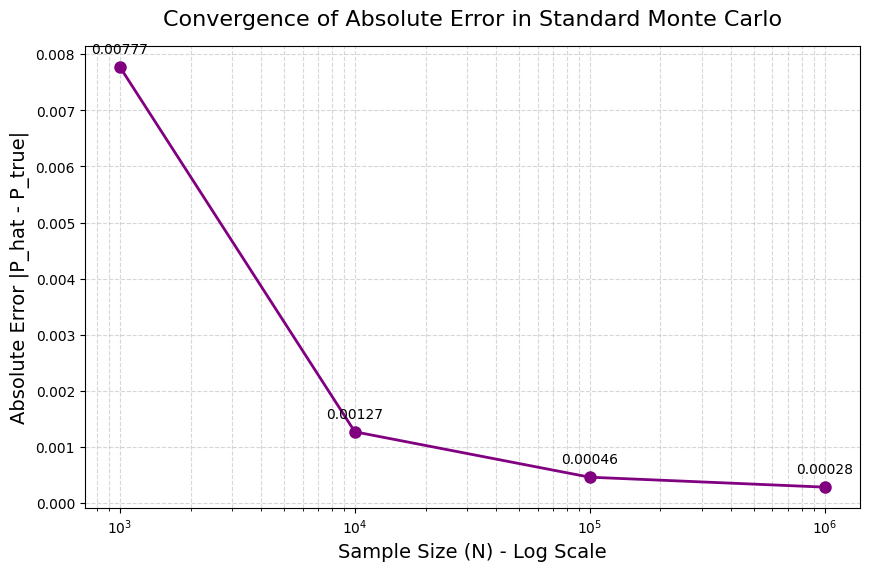

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gamma

shape_f = 6615.4484
loc_f = -122.5883
scale_f = 0.0196

threshold_lower = 4.34  
threshold_upper = 9.75  

#  محاسبه دقیق مقدار واقعی احتمال در توزیع گاما  
p_lower = gamma.cdf(threshold_lower, shape_f, loc=loc_f, scale=scale_f)
p_upper = 1 - gamma.cdf(threshold_upper, shape_f, loc=loc_f, scale=scale_f)
P_true_gamma = p_lower + p_upper

print(f"True Analytical Probability under Gamma Distribution: {P_true_gamma:.6f}")

N_values = [10**3, 10**4, 10**5, 10**6]
results = []

for N in N_values:
    sample_subset = simulated_data[:N]
    
    indicator_values = np.where((sample_subset <= threshold_lower) | (sample_subset >= threshold_upper), 1, 0)
    P_hat = np.mean(indicator_values)
    
    sample_variance = P_hat * (1 - P_hat)
    monte_carlo_variance = sample_variance / N
    
    absolute_error = np.abs(P_hat - P_true_gamma)
    
    results.append({
        'N_int': N,
        'N (Sample Size)': f"10^{int(np.log10(N))}",
        'Estimated Prob (P_hat)': P_hat,
        'Absolute Error': absolute_error,
        'MC Variance (S^2/N)': monte_carlo_variance,
        'Number of Rare Events': np.sum(indicator_values)
    })

results_df = pd.DataFrame(results)

print("\n--- Standard Monte Carlo Results ---")
display_cols = ['N (Sample Size)', 'Estimated Prob (P_hat)', 'Absolute Error', 'MC Variance (S^2/N)', 'Number of Rare Events']
print(results_df[display_cols].to_string(index=False))

plt.figure(figsize=(10, 6))
plt.plot(results_df['N_int'], results_df['Absolute Error'], marker='o', linestyle='-', color='purple', linewidth=2, markersize=8)

plt.xscale('log')
plt.title('Convergence of Absolute Error in Standard Monte Carlo', fontsize=16, pad=15)
plt.xlabel('Sample Size (N) - Log Scale', fontsize=14)
plt.ylabel('Absolute Error |P_hat - P_true|', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)

for i, txt in enumerate(results_df['Absolute Error']):
    plt.annotate(f"{txt:.5f}", (results_df['N_int'][i], results_df['Absolute Error'][i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

plt.show()

# 3: Importance Sampling

selected dist: N(10 , 2.25)

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gamma, norm

#  Model Parameters and Critical Threshold 
# Target distribution parameters (Gamma) - f_X(x)
shape_f = 6615.4484
loc_f = -122.5883
scale_f = 0.0196

# Upper critical threshold (calculated in previous steps)
threshold_upper = 9.75

# Calculate true probability (analytical) for error comparison
# P(X > 9.75) under Gamma distribution
P_true_gamma_upper = 1 - gamma.cdf(threshold_upper, shape_f, loc=loc_f, scale=scale_f)

#  Proposal Distribution Parameters - f_Y(y) 
# We use a Normal distribution shifted towards the critical region
mu_y = 10.0   # Mean shifted into the critical region
sigma_y = 1.5 # Standard deviation of the Normal distribution

print(f"True Probability (Analytical) for pH > {threshold_upper}: {P_true_gamma_upper:.6f}\n")
print("Running Importance Sampling Simulation...")

# N values required by the project
N_values = [10**3, 10**4, 10**5, 10**6]
is_results = []

# --- 3. Execute Importance Sampling Loop ---
for N in N_values:
    # a) Generate N samples directly from the proposal distribution (Shifted Normal)
    # y_i ~ N(10, 1.5)
    y_samples = np.random.normal(loc=mu_y, scale=sigma_y, size=N)
    
    # b) Indicator function: Are the samples in the critical region? (y > 9.75)
    indicator_values = np.where(y_samples >= threshold_upper, 1, 0)
    
    # c) Calculate PDF of generated samples under the target distribution (Gamma) -> f_X(y)
    f_X_y = gamma.pdf(y_samples, shape_f, loc=loc_f, scale=scale_f)
    
    # d) Calculate PDF of generated samples under the proposal distribution (Normal) -> f_Y(y)
    f_Y_y = norm.pdf(y_samples, loc=mu_y, scale=sigma_y)
    
    # e)  Importance Weights
    weights = f_X_y / f_Y_y
    
    #   final probability estimate
    IS_estimate = np.mean(indicator_values * weights)
    
    #  Importance Sampling Variance
    sample_variance_IS = np.var(indicator_values * weights)
    monte_carlo_variance_IS = sample_variance_IS / N
    
    #  Absolute Error
    absolute_error_IS = np.abs(IS_estimate - P_true_gamma_upper)
    
    is_results.append({
        'N (Sample Size)': f"10^{int(np.log10(N))}",
        'N_int': N,
        'IS Estimated Prob': IS_estimate,
        'IS Absolute Error': absolute_error_IS,
        'IS Variance (S^2/N)': monte_carlo_variance_IS,
        'Rare Events Simulated': np.sum(indicator_values)
    })

is_results_df = pd.DataFrame(is_results)
print("\n--- Importance Sampling Results ---")
display_cols = ['N (Sample Size)', 'IS Estimated Prob', 'IS Absolute Error', 'IS Variance (S^2/N)', 'Rare Events Simulated']
print(is_results_df[display_cols].to_string(index=False))

True Probability (Analytical) for pH > 9.75: 0.047362

Running Importance Sampling Simulation...

--- Importance Sampling Results ---
N (Sample Size)  IS Estimated Prob  IS Absolute Error  IS Variance (S^2/N)  Rare Events Simulated
           10^3           0.049944           0.002582         4.055427e-06                    568
           10^4           0.047709           0.000348         3.990086e-07                   5627
           10^5           0.047475           0.000113         3.924096e-08                  56647
           10^6           0.047278           0.000083         3.896723e-09                 566401


Log-Log plot of standard error

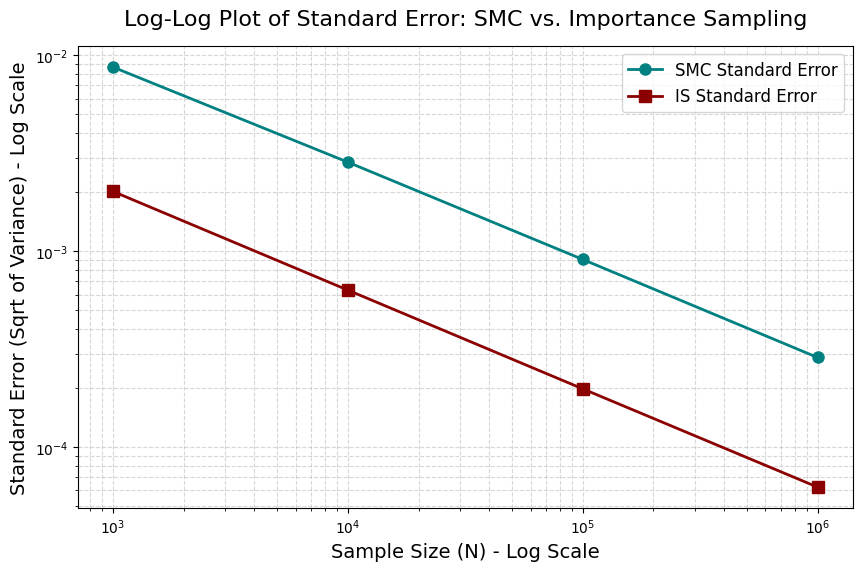

In [17]:
import numpy as np
import matplotlib.pyplot as plt

#  محاسبه خطای استاندارد (رادیکال واریانس) برای روش مونت کارلوی خام
smc_variance = results_df['MC Variance (S^2/N)'].values
smc_std_error = np.sqrt(smc_variance)

#  محاسبه خطای استاندارد (رادیکال واریانس) برای روش نمونه گیری اهمیتی
is_variance = is_results_df['IS Variance (S^2/N)'].values
is_std_error = np.sqrt(is_variance)

N_values = [10**3, 10**4, 10**5, 10**6]

plt.figure(figsize=(10, 6))

plt.loglog(N_values, smc_std_error, marker='o', linestyle='-', color='teal', 
           linewidth=2, markersize=8, label='SMC Standard Error')

plt.loglog(N_values, is_std_error, marker='s', linestyle='-', color='darkred', 
           linewidth=2, markersize=8, label='IS Standard Error')

plt.title('Log-Log Plot of Standard Error: SMC vs. Importance Sampling', fontsize=16, pad=15)
plt.xlabel('Sample Size (N) - Log Scale', fontsize=14)
plt.ylabel('Standard Error (Sqrt of Variance) - Log Scale', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()